# <a id='toc1_'></a>[UMAP: Visão Geral](#toc0_)

## <a id='toc0_'></a> [Sumário](#toc0_)  
 
- [UMAP: Visão Geral](#toc1_)    
  - [Sumário](#toc1_1_)    
  - [Introdução](#toc1_2_)    
  - [O que é UMAP?](#toc1_3_)    
    - [Redução de Dimensionalidade](#toc1_3_1_)    
    - [Abordagens possíveis](#toc1_3_2_)    
  - [Referências](#toc1_4_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

## <a id='toc1_2_'></a>[Introdução](#toc0_)

O objetivo principal desse notebook é apresentar ao leitor uma visão geral do método de **UMAP** (_Uniform Manifold Approximation and Projection_) sem se aprofundar em todos os detalhes matemáticos que permeiam a técnica. (Caso queira entender mais sobre esses detalhes, confira o notebook [01 - UMAP Detalhado](01%20-%20UMAP%20Detalhado.ipynb)). O intuito é propor ao leitor um entendimento abrangente do conceito através de uma breve explicação, possíveis aplicações, e uma lista de materiais complementares.

---

## <a id='toc1_3_'></a>[O que é UMAP?](#toc0_)

O termo **UMAP** significa _Uniform Manifold Approximation and Projection_ (Aproximação e projeção Uniforme de Manifolds) e designa uma técnica de redução de dimensionalidade com uma eficiência computacional elevada baseada em geometria Riemanniana e topologia algébrica. Para entendermos como o UMAP funciona e como podemos aplicá-lo, precisamos primeiramente entender o problema o qual ele se propõe a resolver: a **redução de dimensionalidade**.

### <a id='toc1_3_1_'></a>[Redução de Dimensionalidade](#toc0_)

Vamos supor que possuímos um determinado conjunto de dados sobre pessoas, com dois atributos: _altura_ e _peso_. Sabe-se que podemos simplesmente plotar os dados em um gráfico no qual um dos eixos indica a altura e outro o peso, como na [Figura 1](#grafico_peso_altura).

<img src="../assets/grafico_peso_altura.png" width=300px id="grafico_peso_altura"> <br/>
**Figura 1:** Gráfico ilustrativo com eixos _peso_ e _altura_. <br/>
<small>Fonte: Autoria própria</small>

A partir do gráfico, conseguimos visualizar os dados e entendê-los de uma forma mais adequada. Por exemplo, nesse gráfico é possível distinguir dois grupos de dados que provavelmente indicam pessoas semelhantes, além de alguns pontos que se distanciam dos outros grupos, indicando possíveis anomalias, como mostra a [Figura 2](#grafico_peso_altura_clusters)

<img src="../assets/grafico_peso_altura_clusters.png" width=300px id="grafico_peso_altura_clusters"> <br/>
**Figura 2:** Gráfico ilustrativo com eixos _peso_ e _altura_. Grupos semelhantes de dados estão com a mesma cor (azul e vermelho). Os pontos em verde representam valores discrepantes. <br/>
<small>Fonte: Autoria própria</small>

Se nosso conjunto de dados possuisse mais um atributo, idade, por exemplo, então precisaríamos de um gráfico tridimensional para visualizar a distribuição dos dados, o que já pode dificultar um pouco a interpretação, mas ainda é possível.

<img src="../assets/grafico_peso_altura_idade.png" width=300px id="grafico_peso_altura_idade"> <br/>
**Figura 3:** Gráfico ilustrativo com eixos _peso_, _altura_ e _idade_. Grupos semelhantes de dados estão com a mesma cor (azul e vermelho). Os pontos em verde representam valores discrepantes. <br/>
<small>Fonte: Autoria própria</small>

Mas quando esse conjunto começa a ter 4, 10, ou até mesmo centenas de atributos distintos, a visualização clara de agrupamentos por uma simples plotagem se torna invisível.

É justamente nesse contexto que entra a **redução de dimensionalidade**. O objetivo aqui é tentar projetar o conjunto de dados em um número menor de dimensões, sem perder as relações de vizinhança e estrutura, para conseguir visualizá-los e interpretá-los melhor. A redução de dimensionalidade também pode ser útil para pré-processamento de dados ao induzir um modelo de machine learning, por exemplo, principalmente se existem muitos atributos redundantes ou talvez ruidosos.

### <a id='toc1_3_2_'></a>[Abordagens existentes](#toc0_)

Para resolver esse problema, diversas abordagens surgiram ao longo do tempo, cada uma com suas vantagens e desvantagens. Vamos pensar em um conjunto bidimensional qualquer, com atributos _X_ e _Y_:

<img src="../assets/grafico_x_y.png" width=300px id="grafico_x_y"> <br/>
**Figura 4:** Gráfico ilustrativo com eixos _X_ e _Y_.<br/>
<small>Fonte: Autoria própria</small>

Novamente, conseguimos observar 3 agrupamentos (ou _clusters_) de dados:

<img src="../assets/grafico_x_y_clusters.png" width=300px id="grafico_x_y_clusters"> <br/>
**Figura 5:** Gráfico ilustrativo com eixos _X_ e _Y_. As cores representam os agrupamentos de dados semelhantes<br/>
<small>Fonte: Autoria própria</small>

Nosso objetivo aqui será reduzir a dimensionalidade desses dados para uma única linha.

Um método trivial que poderíamos utilizar para fazer isso, seria apenas projetar os dados em um dos eixos, mas note que isso não resolve nosso problema, pois observações distintas ficam próximas e as relações de vizinhanças não são mantidas.

<img src="../assets/grafico_x_y_projecao.png" width=300px id="grafico_x_y_projecao"> <br/>
**Figura 6:** Gráfico ilustrativo com eixos _X_ e _Y_. As cores representam os agrupamentos de dados semelhantes. Os dados estão sendo projetados em direção ao eixo _X_, criando um novo conjunto com dimensão reduzida<br/>
<small>Fonte: Autoria própria</small>

Então precisamos encontrar uma forma de reduzir a dimensionalidade sem perder essas relações, e para isso foram criadas diferentes estratégias. Algumas focam em preservar a estrutura de distância global das amostras, como o _PCA_, o _MDS_, ou o _Sammon mapping_, enquanto outras favorecem a preservação de estruturas locais, como o _t-SNE_, o _Isomap_, o _LargeVis_, a _imersão Laplaciana_ ou _mapas de difusão_. [[3](#referencias)]

Cada uma dessas estratégias possui suas vantagens e desvantagens, podendo ser uma alternativa adequada dependendo do conjunto de dados e da disponibilidade de tempo e de computação. O _UMAP_ surge justamente como uma tentativa de unir o melhor dos mundos, apresentando-se como um algorítmo que tenta preservar as relações locais sem se disfazer da estrutura global, além de apresentar um desempenho computacional superior ao de algorítmos frequentemente utilizados como o _t-SNE_, o qual era considerado por muitos como o estado da arte na questão de redução de dimensionalidade.

Caso queira entender mais sobre o funcionamento de alguns algorítimos específicos, recomendo a referência [[4](#referencias)] para conhecer a técnica de _PCA_ e a referência [[5](#referencias)] para entender a lógica simplificada do _t-SNE_.

### Como funciona o UMAP?

Então agora, sem mais delongas, podemos finalmente explicar como é o funcionamento real do _UMAP_. Todas as decisões tomadas durante a construção do algorítmo possuem uma base matemática sólida e justificações lógicas, porém não entraremos nesses detalhes por enquanto. Apesar do detalhamento algébrico, é fácil entender de forma intuititva o mecânismo essencial da técnica.

Essencialmente, o funcionamento do UMAP se assemelha muito ao do t-SNE, construindo uma representação topológica hiperdimensional dos dados e otimizando uma representação equivalente em um espaço de baixa dimensão para aproximá-la da estrutura original. O real poder do UMAP está na forma como ele cria a representação topólogica hiperdimensional.

Primeiramente, ele constrói uma estrutura conhecida como _complexo simplicial fuzzy_, o qual pode ser entendido como a representação de um grafo ponderado no qual cada aresta indica a probabilidade de dois pontos estarem conectados. Para determinar o grau dessa relação, o UMAP cria um raio a partir de cada ponto e define a conexão a partir do encontro desses raios.

Entretanto, temos um problema: como escolher o tamanho dos raios? Se escolhermos um raio fixo, regiões densas vão ter muita conexões enquanto regiões mais esparsas poderiam ter pontos sem conexão nenhuma, mas para aplicar as teorias algébricas necessárias precisamos de um conjunto uniforme.

Como praticamente nenhum conjunto de dados real é tão uniforme assim, o UMAP toma outra decisão: os raios são escolhidos localmente, baseado na distância até o _n_ vizinho mais próximo. Outra adição do UMAP é escolher um raio difuso, o qual diminui a força de acordo com a distância.

Por último, precisamos que o manifold seja localmente conectado, então cada ponto é conectado pelo menos com seu vizinho mais próximo, sem deixar nenhum dado isolado.

O código a seguir monta um gráfico interativo, demonstrando a construção do complexo, inspirado nas referências [[6](#referencias)] e [[7](#referencias)].

In [118]:
import matplotlib.pyplot as plt
import matplotlib.lines as lines
import numpy as np

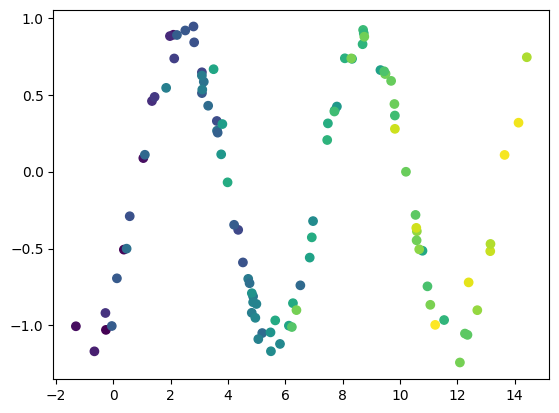

In [122]:
x = np.array([i + np.random.uniform(-2,2) for i in np.linspace(0, np.pi * 4, 100)])
y = np.array([i + np.random.normal(-0.1,0.1) for i in np.sin(x+np.random.uniform(-40,40))])
dados = np.array([[x[i], y[i]] for i in range(len(x))])

n_neighbors = 1
connections = []

for i, p in enumerate(dados):
    min_dist = float("inf")
    nearest_neighbor = i
    
    for j, p2 in enumerate(dados):
        dist = np.sqrt((p[0]-p2[0])**2 + (p[1]-p2[1])**2)
        if dist < min_dist:
            min_dist = dist
            nearest_neighbor = j
    
    connections.append((dados[i], dados[nearest_neighbor]))
    

plt.scatter(x, y, c=t)
lines.Line2D(connections, y)
plt.show()

<span id="referencias"></span>
## <a id='toc1_4_'></a>[Referências](#toc0_)

1. **STATQUEST WITH JOSH STARMER.** *UMAP: Main Ideas!!!*. YouTube, 2023. Disponível em: <https://www.youtube.com/watch?v=eN0wFzBA4Sc>. Acesso em: 9 set. 2026.

2. **STATQUEST WITH JOSH STARMER.** *UMAP: Mathematical Details*. YouTube, 2023. Disponível em: <https://www.youtube.com/watch?v=jth4kEvJ3P8>. Acesso em: 9 set. 2026.

3. **MCINNES, Leland; HEALY, John; MELVILLE, James.** *UMAP: Uniform Manifold Approximation and Projection for Dimension Reduction*. arXiv, 2018. Disponível em: <https://arxiv.org/abs/1802.03426>. Acesso em: 9 set. 2026.

4. **STATQUEST WITH JOSH STARMER.** *StatQuest: Principal Component Analysis (PCA), Step-by-Step*. YouTube, 2018. Disponível em: <https://www.youtube.com/watch?v=FgakZw6K1QQ>. Acesso em: 9 set. 2026.

5. **STATQUEST WITH JOSH STARMER.** *StatQuest: t-SNE clearly explained*. YouTube, 2018. Disponível em: <https://www.youtube.com/watch?v=NEaUSP4YerM>. Acesso em: 9 set. 2026.

6. **COENEN, Andy; PEARCE, Adam.** *Understanding UMAP*. Google PAIR, [s. d.]. Disponível em: <https://pair-code.github.io/understanding-umap/>. Acesso em: 11 set. 2026.

7. **MCINNES, Leland.** *UMAP: Uniform Manifold Approximation and Projection for Dimensional Reduction*. YouTube, 2018. Disponível em: <https://www.youtube.com/watch?v=nq6iPZVUxZU>. Acesso em: 11 set. 2026.

8. **NUMPY DEVELOPERS.** *NumPy documentation*. [S. l.], 2026. Disponível em: <https://numpy.org/doc/stable/index.html>. Acesso em: 11 set. 2026.

9. **MATPLOTLIB DEVELOPMENT TEAM.** *Matplotlib 3.11.1 documentation*. [S. l.], 2026. Disponível em: <https://matplotlib.org/stable/>. Acesso em: 11 set. 2026.